# Monte Carlo cost-risk model: walkthrough

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Divyaprakash-SM/Monte-Carlo-Simulation/blob/main/notebooks/Monte_Carlo_Walkthrough.ipynb)

This notebook runs the full model on a Work Breakdown Structure (WBS) and shows every output: the cost range, the S-curve, what drives the uncertainty, and the cost of each milestone.

Run the cells top to bottom. It uses the fictional sample project by default; set `USE_MY_FILE = True` in step 2 to upload your own sheet.

## 1. Set up

In [1]:
import os, sys

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.exists("Monte-Carlo-Simulation"):
        !git clone -q https://github.com/Divyaprakash-SM/Monte-Carlo-Simulation.git
    %cd Monte-Carlo-Simulation
    !pip install -q -r requirements.txt
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

sys.path.insert(0, os.getcwd())
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from montecarlo import (Settings, load_wbs, check_subtotals, run, project_summary,
                        milestone_summary, sensitivity, export_excel, charts)
pd.set_option("display.float_format", "{:,.2f}".format)

## 2. Choose the input file

The sheet needs `WBS Code`, `Task` and `Cost` columns. `Optimistic Cost`, `Pessimistic cost`, `Risk - Likelihood` and `Risk % multiplier` are optional. See the README for the full format.

In [2]:
USE_MY_FILE = False   # set to True to upload your own Excel or CSV file

path = "data/sample_wbs.xlsx"
if USE_MY_FILE:
    if IN_COLAB:
        from google.colab import files
        uploaded = files.upload()
        path = next(iter(uploaded))
    else:
        path = input("Path to your WBS file: ").strip()

tasks, summaries = load_wbs(path)
print(f"{len(tasks)} tasks loaded; {len(summaries)} milestone/sub-total rows excluded so nothing is counted twice.")
for note in check_subtotals(tasks, summaries):
    print("Note:", note)
tasks[["WBS Code", "Task", "Milestone", "Cost", "Risk Likelihood", "Risk Multiplier"]]

17 tasks loaded; 4 milestone/sub-total rows excluded so nothing is counted twice.
Note: WBS 1.2 (Requirements and process mapping) has sub-tasks but its cost (5,600) is not their total (4,200), so it is treated as a task in its own right.
Note: WBS 3.3 (Performance and security testing) has sub-tasks but its cost (4,900) is not their total (3,500), so it is treated as a task in its own right.


,WBS Code,Task,Milestone,Cost,Risk Likelihood,Risk Multiplier
0,1.1,Stakeholder workshops,Milestone 01 - Discovery and Design,"3,500.00",2.00,0.20
1,1.2,Requirements and process mapping,Milestone 01 - Discovery and Design,"5,600.00",3.00,0.40
2,1.2.1,Data audit of legacy systems,Milestone 01 - Discovery and Design,"4,200.00",4.00,0.60
3,1.3,Solution architecture,Milestone 01 - Discovery and Design,"7,000.00",2.00,0.40
4,1.4,Design sign-off and governance,Milestone 01 - Discovery and Design,"1,400.00",2.00,0.20
5,2.1,Core platform configuration,Milestone 02 - Build and Integration,"16,800.00",3.00,0.40
6,2.2,Data migration scripts,Milestone 02 - Build and Integration,"11,200.00",4.00,0.60
7,2.3,Third-party integrations,Milestone 02 - Build and Integration,"12,600.00",5.00,0.80
8,2.4,Reporting dashboards,Milestone 02 - Build and Integration,"6,300.00",2.00,0.20
9,3.1,System testing,Milestone 03 - Testing,"8,400.00",3.00,0.40


## 3. Set the assumptions

| Setting | What it means |
|---|---|
| `n_sims` | how many times the project is simulated |
| `optimistic_factor`, `pessimistic_factor` | the range used when a task has no optimistic or pessimistic cost of its own (default 90% to 120%) |
| `risk_mode` | `"loaded"`: every task is priced up by its risk multiplier (the dissertation method). `"event"`: each risk happens or not, with a chance of likelihood / 6. `"none"`: estimate uncertainty only |
| `correlation` | 0 treats tasks as independent. 0.2 to 0.4 models the shared drift real projects see (one delay tends to bring others) |

In [3]:
settings = Settings(n_sims=10_000, optimistic_factor=0.90, pessimistic_factor=1.20,
                    risk_mode="loaded", correlation=0.0, seed=42)

estimates, results = run(tasks, settings=settings)
summary = project_summary(results, estimates)
summary[["Model", "Base estimate", "Mean", "P10", "P50", "P80", "P90", "Std Dev", "Contingency at P80 (%)"]]

,Model,Base estimate,Mean,P10,P50,P80,P90,Std Dev,Contingency at P80 (%)
0,Triangular,"106,400.00","160,906.21","155,633.92","160,755.64","164,533.80","166,455.44","4,157.29",54.64
1,Lognormal,"106,400.00","155,954.03","149,851.31","155,687.39","160,014.01","162,441.07","4,936.66",50.39
2,Beta-PERT,"106,400.00","158,083.56","153,312.11","157,953.50","161,344.19","163,081.03","3,748.23",51.64


## 4. The S-curve: how confident can you be in a budget?

Read across from any probability to the cost. The dots mark P80, the confidence level most organisations budget to.

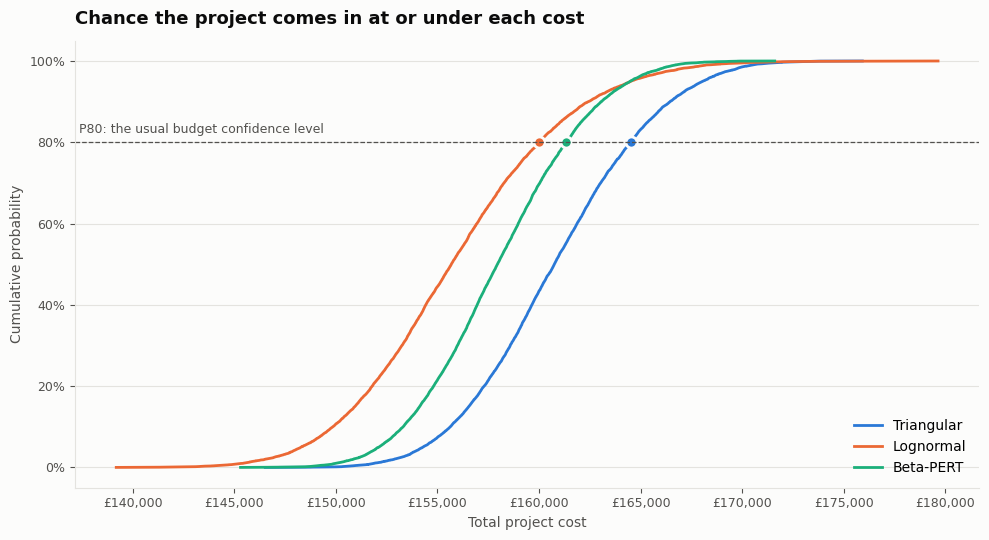

In [4]:
charts.s_curve(results); plt.show()

## 5. One model in detail

Change `MODEL` to `"triangular"` or `"lognormal"` to compare.

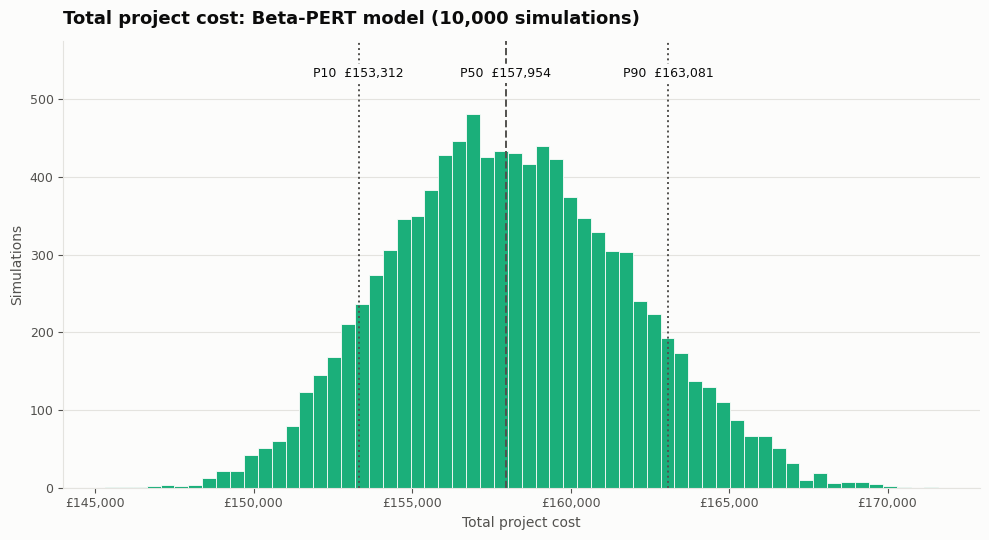

In [5]:
MODEL = "pert"
res = results[MODEL]
charts.distribution(res); plt.show()

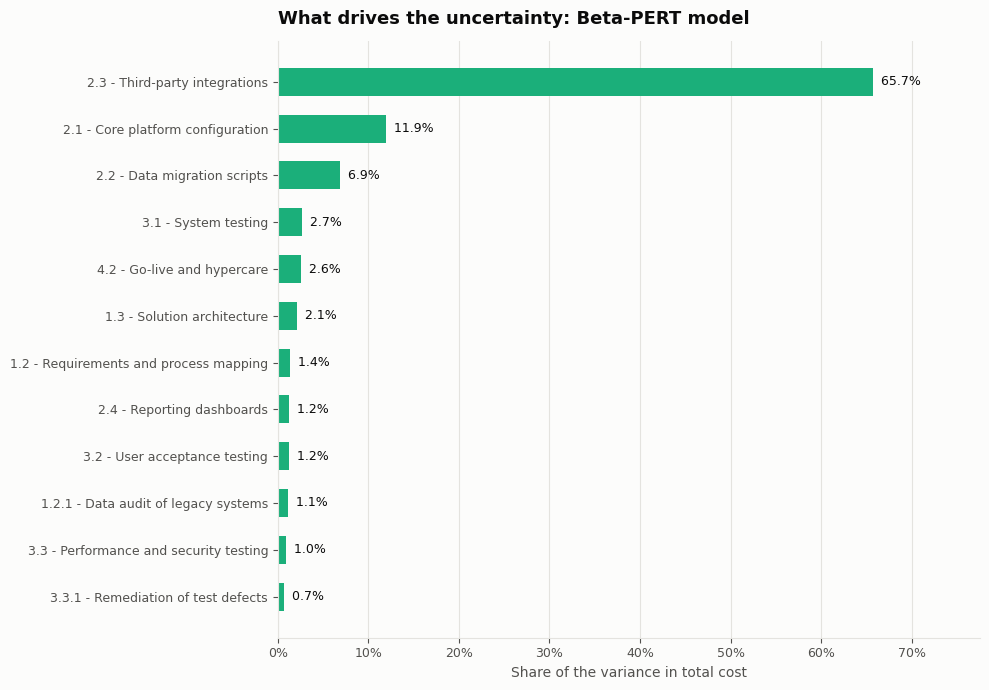

,Task,Mean cost,Share of variance (%),Correlation with total
0,2.3 - Third-party integrations,"23,225.02",65.72,0.81
1,2.1 - Core platform configuration,"23,896.98",11.91,0.35
2,2.2 - Data migration scripts,"18,208.84",6.88,0.26
3,3.1 - System testing,"11,960.65",2.70,0.16
4,4.2 - Go-live and hypercare,"11,385.56",2.58,0.16
5,1.3 - Solution architecture,"9,970.20",2.09,0.14
6,1.2 - Requirements and process mapping,"7,974.88",1.38,0.12
7,2.4 - Reporting dashboards,"7,692.15",1.19,0.11
8,3.2 - User acceptance testing,"7,972.84",1.18,0.10
9,1.2.1 - Data audit of legacy systems,"6,828.87",1.10,0.11


In [6]:
sens = sensitivity(res)
charts.tornado(sens, res); plt.show()
sens.head(10)

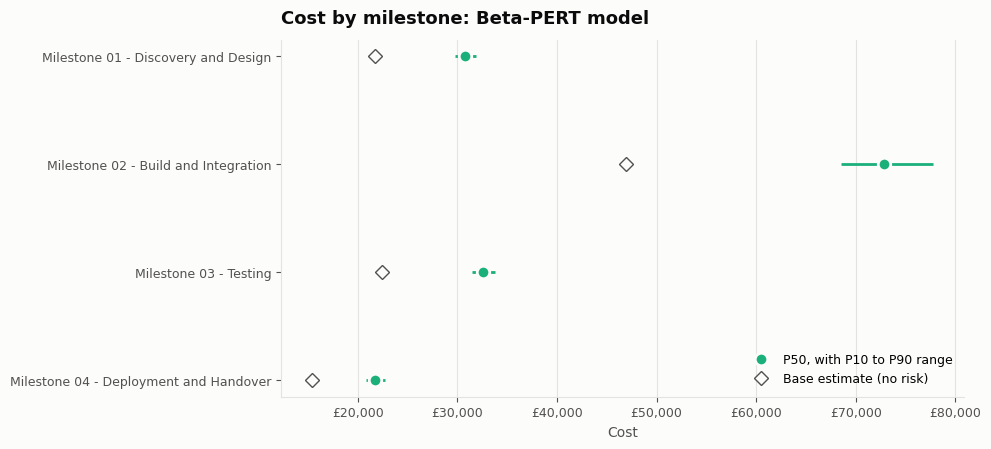

,Milestone,Base estimate,P10,P50,P80,P90
0,Milestone 01 - Discovery and Design,"21,700.00","29,708.21","30,726.30","31,453.69","31,860.35"
1,Milestone 02 - Build and Integration,"46,900.00","68,565.43","72,882.25","76,095.95","77,770.94"
2,Milestone 03 - Testing,"22,400.00","31,432.97","32,575.12","33,381.95","33,800.62"
3,Milestone 04 - Deployment and Handover,"15,400.00","20,774.53","21,677.55","22,329.74","22,669.95"


In [7]:
ms = milestone_summary(res, estimates)
charts.milestones(ms, res); plt.show()
ms[["Milestone", "Base estimate", "P10", "P50", "P80", "P90"]]

## 6. Export everything to Excel

In [8]:
out = export_excel(results, estimates, "outputs/results.xlsx")
print("Saved", out)
if IN_COLAB:
    from google.colab import files
    files.download(str(out))

Saved outputs/results.xlsx
